# NB04 — Can we tell at minute 0 whether a provider incident will be long?

## 1. The question

A provider posts a new incident on its status page, and the on-call engineer has thirty seconds to decide whether to treat it as noise or start paging people. The question this notebook tests: does the information available at that exact moment (minute 0, before anything else has happened) predict whether the incident will turn out LONG, meaning above the 75th percentile of duration across the combined dataset? Everything below is built to answer that question honestly, which turns out to mean spending most of the effort catching the model in the act of cheating.

## 2. Why this question matters

The decision this informs is the early-escalation policy: when a provider posts a new incident, the on-call engineer has to decide right then whether this is a wait-it-out event or something that gets a senior paged, a war room opened, and customers proactively told. If minute-0 information carries real signal about eventual duration, escalation can be front-loaded. If it does not, the honest policy is to escalate on elapsed time ("if still open after N minutes, escalate"), not on a guess made before anything has happened.

I fix the expected honest outcome here, before running anything: with the features legitimately available at t=0, I expect AUC somewhere in the 0.5–0.7 range. An AUC near 0.9 would not be a win; it would be evidence of leakage, meaning information from after t=0 has snuck into the features. A near-null result with an honest confidence interval is itself a legitimate finding — it tells the decision-maker to stop looking for a minute-0 crystal ball.

### The leakage problem this notebook is built around

The dataset is a single snapshot of each provider's status page, and status pages upgrade the impact label as an incident unfolds (minor becomes major becomes critical). What I captured is therefore almost certainly the settled, final impact, not the minute-0 declaration, and the final impact partially encodes the outcome I am trying to predict: long incidents get upgraded. I cannot un-leak the column, but I can measure the leak, with two models. Model A, the optimistic ceiling, fits provider + settled_impact + business_hours and knowingly includes outcome information, which means its AUC is an upper bound, not an estimate. Model B is the honest t=0 estimate: the same model without settled_impact. The gap between A and B is the finding — it measures how much of the apparent predictability was leaked outcome dressed up as a feature.

## 3. The data and its limits

`data/real/service_incidents.csv` holds 787 incidents scraped from the public status pages of 18 cloud providers (GitHub, Anthropic, GCP, Cloudflare, Vercel, npm, Datadog, Twilio, Dropbox, Discord, Linear, Atlassian, Reddit, OpenAI, DigitalOcean, CircleCI, Zoom, Figma). 774 have a resolved timestamp and hence a duration. GCP contributes zero resolved incidents and drops out of the analysis entirely, leaving 17 providers.

I fix the limits below before touching a model, so a later result reads as evidence rather than as something I talked myself into after the fact:

1. Status-page censoring. Providers only publish incidents they chose to declare, so I observe *declared* incidents, not all failures.
2. Wildly different observation windows. Each provider's API returns roughly its last ~50 incidents, so the window covered differs by orders of magnitude across providers (days for Twilio, years for Atlassian, computed below). This forbids pooling *rates* across providers. The unit of analysis here is the individual incident and the target is a duration property, which stays comparable across providers; any per-provider frequency statement does not.
3. Impact conventions are not comparable across providers. Figma and Atlassian label almost everything `none`, Discord uses `major` liberally, and Twilio uses `minor` almost exclusively (verified below). An impact label only means something relative to its own provider's labeling habits, so wherever impact enters a model, provider comes along as a covariate, and impact never gets used alone as a pooled feature. (I still fit an impact-only model below, but strictly as a baseline to beat, not as a proposed predictor.)
4. The Twilio caveat. 45 incidents inside an 8-day window with a long median duration, most likely one platform crisis generating correlated incidents, not 45 independent events. I keep Twilio but run the headline models with and without it.
5. `affected_components` is excluded a priori. It is populated for 88% of Anthropic incidents versus 54% of GitHub incidents (verified below), which means the field encodes provider reporting habits, not incident characteristics.
6. Sparse features. What's available is provider, settled impact, timestamps, component lists, and title text, with no provider-internal telemetry. The feature set stays capped a priori (Section 4).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score

rng = np.random.default_rng(20240401)

raw = pd.read_csv("data/real/service_incidents.csv")
d = raw.dropna(subset=["duration_min"]).copy()
d["created_at"] = pd.to_datetime(d["created_at"], format="ISO8601", utc=True)

P75 = d["duration_min"].quantile(0.75)
d["long"] = (d["duration_min"] > P75).astype(int)

print(f"Rows captured: {len(raw)}  |  with duration: {len(d)}  |  providers with duration: {d['provider'].nunique()}")
print(f"P75 of duration (combined, recomputed): {P75:.1f} min  (~{P75/60:.1f} h)")
print(f"Positives (LONG = duration > P75): {d['long'].sum()}  ({d['long'].mean():.1%})")

Rows captured: 787  |  with duration: 774  |  providers with duration: 17
P75 of duration (combined, recomputed): 209.2 min  (~3.5 h)
Positives (LONG = duration > P75): 194  (25.1%)


### Per-provider observation windows

Each provider's window is `[min(created_at), max(created_at)]` of *its own* incidents. The spread below is why cross-provider **rate** comparisons are forbidden without per-window normalization. Duration comparisons (this notebook's target) remain valid across providers.

In [2]:
windows = d.groupby("provider")["created_at"].agg(["min", "max", "count"])
windows["window_days"] = (windows["max"] - windows["min"]).dt.days
print(windows[["count", "window_days"]].sort_values("window_days").to_string())
print(f"\nWindow span across providers: {windows['window_days'].min()} days (twilio) "
      f"to {windows['window_days'].max()} days (atlassian, ~{windows['window_days'].max()/365:.1f} years)")

                  count  window_days
provider                            
twilio               45            8
cloudflare           48           21
openai               24           23
claude_anthropic     49           29
github               50           64
zoom                 50           65
vercel               50           93
linear               25           98
digitalocean         49          135
circleci             50          211
datadog              50          303
discord              50          324
reddit               50          755
dropbox              50          775
figma                50          981
npm                  50          990
atlassian            34         2128

Window span across providers: 8 days (twilio) to 2128 days (atlassian, ~5.8 years)


### Verifying the declared caveats against the data

Two checks promised above: (a) impact conventions differ across providers, (b) `affected_components` population differs by provider.

In [3]:
conv = pd.crosstab(d["provider"], d["impact"], normalize="index").round(2)
print("Impact label mix by provider (row proportions):")
print(conv[["none", "minor", "major", "critical"]].to_string())

comp = raw.groupby("provider")["affected_components"].apply(lambda s: s.notna().mean())
print(f"\naffected_components populated: anthropic {comp['claude_anthropic']:.0%} vs github {comp['github']:.0%}"
      "  -> excluded as a feature (encodes reporting practice, not the incident)")

Impact label mix by provider (row proportions):
impact            none  minor  major  critical
provider                                      
atlassian         0.76   0.03   0.18      0.03
circleci          0.14   0.62   0.20      0.04
claude_anthropic  0.06   0.73   0.18      0.02
cloudflare        0.17   0.81   0.02      0.00
datadog           0.04   0.44   0.36      0.16
digitalocean      0.27   0.63   0.10      0.00
discord           0.28   0.22   0.46      0.04
dropbox           0.16   0.76   0.08      0.00
figma             0.80   0.14   0.06      0.00
github            0.10   0.56   0.08      0.26
linear            0.16   0.60   0.16      0.08
npm               0.06   0.74   0.18      0.02
openai            0.04   0.88   0.08      0.00
reddit            0.24   0.36   0.36      0.04
twilio            0.11   0.89   0.00      0.00
vercel            0.08   0.74   0.18      0.00
zoom              0.20   0.80   0.00      0.00

affected_components populated: anthropic 88% vs github 54%

The convention differences are stark: Figma labels 80% of its incidents `none` and Atlassian 76%, while Discord calls 46% of its incidents `major` and Twilio labels 89% `minor` with zero `major`/`critical`. The same word means different things on different status pages. This is the empirical basis for the rule that **provider must always accompany impact** in any model: without the provider covariate, the model would read "Discord major" and "Datadog major" as the same signal, when they are drawn from entirely different labeling policies.

## 4. Method and assumptions

Target: `long = duration_min > P75`, with P75 recomputed on the combined 774-duration dataset (printed above: ~209 min).

Features: I cap and fix these before touching the outcomes, as a rule I'd recommend to anyone tempted to peek — data-driven selection at this stage is leakage by another name.

| Feature | In Model A | In Model B | Note |
|---|---|---|---|
| `provider` (17 levels) | yes | yes | declared upfront as the likely dominant signal |
| `settled_impact` (4 levels) | yes | no | known leak (captured post hoc, not at t=0) |
| `business_hours` (weekday, 9–18 UTC of `created_at`) | yes | yes | available at t=0 by construction |

Excluded a priori: `affected_components` (provider-asymmetric reporting, shown above), title text and title length (feature-budget discipline), and anything derived from `resolved_at` or `status` (trivially post-t=0).

Estimator: logistic regression with L2 regularization (C=1). No gradient boosting, no interactions, because the events-per-variable budget (computed below) supports a small linear model, nothing more.

Evaluation runs on four fixed choices. Stratified 5-fold cross-validation produces out-of-fold predicted probabilities, pooled, with AUC computed once on the pooled predictions. Two baselines have to be beaten: always predicting the majority class (AUC = 0.5 by construction), and an impact-only logistic model (also leaky, kept purely as a reference for how much the settled label alone knows). AUC confidence intervals come from a class-stratified bootstrap, 2,000 replicates, with positives and negatives resampled separately; a plain bootstrap on 194 positives can produce degenerate replicates with very few positives, which inflates the CI. And what CV does and does not measure is worth stating outright: stratified k-fold measures generalization across a random split of this observation period. It does not measure generalization to future incidents, which is what an escalation policy actually needs. With single-snapshot data there is no honest temporal holdout available, so I say so rather than pretend.

Events per variable (EPV). Before the provider expansion this analysis was infeasible: 25 positives against ~13 parameters gave EPV ≈ 2, far below the conventional floor of 10. With 194 positives it is now adequate, computed exactly below.

In [4]:
# ---- Assumption checks, executed ----
d["biz"] = ((d["created_at"].dt.weekday < 5)
            & (d["created_at"].dt.hour >= 9)
            & (d["created_at"].dt.hour < 18)).astype(int)

n_pos = int(d["long"].sum())
p_A = (d["provider"].nunique() - 1) + (d["impact"].nunique() - 1) + 1   # dummies + biz
p_B = (d["provider"].nunique() - 1) + 1
print(f"EPV check: {n_pos} positives | Model A: {p_A} parameters -> EPV = {n_pos/p_A:.1f} | "
      f"Model B: {p_B} parameters -> EPV = {n_pos/p_B:.1f}")
print("  (before the 2026-07-03 provider expansion: 25 positives, EPV ~ 2 -> the model was infeasible)")

print(f"\nbusiness_hours prevalence: {d['biz'].mean():.1%} of incidents created weekday 9-18 UTC")
print("LONG rate by business_hours:")
print(d.groupby("biz")["long"].agg(["mean", "count"]).round(3).to_string())

# Leakage checklist over the columns actually used
used = ["provider", "impact", "created_at"]
post_t0 = ["resolved_at", "duration_min", "status"]
assert not set(used) & set(post_t0)
print(f"\nLeakage checklist: features built only from {used};"
      f" columns {post_t0} touch only the TARGET definition.")
print("Remaining declared leak: 'impact' is the SETTLED value (single snapshot), not the minute-0 declaration.")

EPV check: 194 positives | Model A: 20 parameters -> EPV = 9.7 | Model B: 17 parameters -> EPV = 11.4
  (before the 2026-07-03 provider expansion: 25 positives, EPV ~ 2 -> the model was infeasible)

business_hours prevalence: 41.1% of incidents created weekday 9-18 UTC
LONG rate by business_hours:
      mean  count
biz              
0    0.259    456
1    0.239    318

Leakage checklist: features built only from ['provider', 'impact', 'created_at']; columns ['resolved_at', 'duration_min', 'status'] touch only the TARGET definition.
Remaining declared leak: 'impact' is the SETTLED value (single snapshot), not the minute-0 declaration.


Running the checks I promised above: EPV comes out to ~9.7 for Model A and ~11.4 for Model B, around the conventional floor of 10, not comfortably above it, which is exactly why the feature set stays capped and the regression stays L2-regularized with no interactions. (The pre-expansion version, at EPV ≈ 2, would not have been fittable at all.) Business hours shows essentially no marginal signal (a LONG rate of 23.9% inside business hours versus 25.9% outside), and it stays in anyway, because it was fixed a priori; dropping it now because it looks weak would be exactly the post hoc selection this notebook is designed to avoid.

One more thing declared before fitting: the per-provider LONG rates below already make clear that provider is expected to be the dominant predictor, and that Twilio (the probable correlated-crisis cluster) is expected to be the most extreme one.

                  long_rate  n_long   n
provider                               
claude_anthropic      0.061       3  49
linear                0.080       2  25
datadog               0.100       5  50
circleci              0.160       8  50
discord               0.180       9  50
reddit                0.180       9  50
npm                   0.180       9  50
openai                0.208       5  24
github                0.220      11  50
zoom                  0.260      13  50
vercel                0.260      13  50
digitalocean          0.286      14  49
cloudflare            0.312      15  48
atlassian             0.353      12  34
dropbox               0.360      18  50
figma                 0.420      21  50
twilio                0.600      27  45


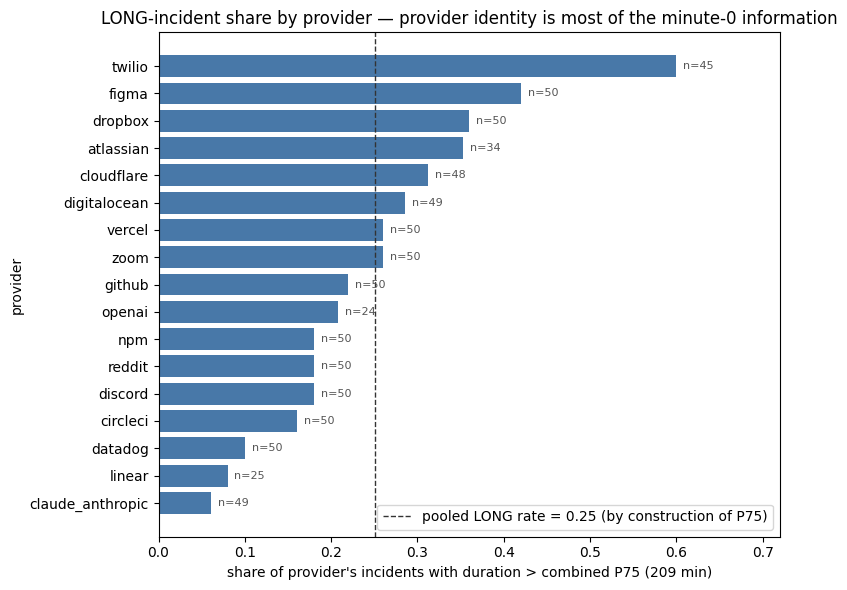

In [5]:
prov = (d.groupby("provider")["long"].agg(long_rate="mean", n_long="sum", n="count")
          .sort_values("long_rate"))
print(prov.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(prov.index, prov["long_rate"], color="#4878a8")
ax.axvline(d["long"].mean(), color="#333333", linestyle="--", linewidth=1,
           label=f"pooled LONG rate = {d['long'].mean():.2f} (by construction of P75)")
for i, (rate, n) in enumerate(zip(prov["long_rate"], prov["n"])):
    ax.text(rate + 0.008, i, f"n={n}", va="center", fontsize=8, color="#555555")
ax.set_xlabel("share of provider's incidents with duration > combined P75 (209 min)")
ax.set_ylabel("provider")
ax.set_xlim(0, 0.72)
ax.set_title("LONG-incident share by provider — provider identity is most of the minute-0 information")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

Twilio (60% LONG) and Anthropic (6% LONG) span a 10x range in LONG share — the chart compares a duration property across providers, which is legitimate, and says nothing about incident rates, which would need per-window normalization first.

### Fitting and evaluating the four models

In [6]:
y = d["long"].values

def cv_oof_probs(cols):
    """Pooled out-of-fold predicted probabilities from stratified 5-fold CV."""
    X = d[cols]
    cat_cols = [c for c in cols if c != "biz"]
    ct = ColumnTransformer(
        [("onehot", OneHotEncoder(handle_unknown="ignore"), cat_cols)],
        remainder="passthrough")
    pipe = Pipeline([("enc", ct), ("lr", LogisticRegression(C=1.0, max_iter=2000))])  # L2 is the default penalty
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=20240401)
    probs = np.zeros(len(d))
    for tr, te in skf.split(X, y):
        pipe.fit(X.iloc[tr], y[tr])
        probs[te] = pipe.predict_proba(X.iloc[te])[:, 1]
    return probs

probs_A = cv_oof_probs(["provider", "impact", "biz"])   # optimistic ceiling, leakage declared
probs_B = cv_oof_probs(["provider", "biz"])              # honest t=0 estimate
probs_impact = cv_oof_probs(["impact"])                  # leaky baseline: settled impact alone
probs_majority = np.zeros(len(d))                        # majority-class baseline

auc = {name: roc_auc_score(y, p) for name, p in
       [("A", probs_A), ("B", probs_B), ("impact_only", probs_impact), ("majority", probs_majority)]}
for k, v in auc.items():
    print(f"AUC {k:12s}: {v:.3f}")

AUC A           : 0.643
AUC B           : 0.636
AUC impact_only : 0.539
AUC majority    : 0.500


In [7]:
# Class-stratified bootstrap CIs (resample positives and negatives separately), 2000 reps.
pos_idx, neg_idx = np.where(y == 1)[0], np.where(y == 0)[0]
B_REPS = 2000

def stratified_boot_auc(p):
    aucs = np.empty(B_REPS)
    for b in range(B_REPS):
        idx = np.concatenate([rng.choice(pos_idx, len(pos_idx), replace=True),
                              rng.choice(neg_idx, len(neg_idx), replace=True)])
        aucs[b] = roc_auc_score(y[idx], p[idx])
    return np.percentile(aucs, [2.5, 97.5])

ci = {}
for name, p in [("A", probs_A), ("B", probs_B), ("impact_only", probs_impact)]:
    ci[name] = stratified_boot_auc(p)
    print(f"AUC {name:12s}: {auc[name]:.3f}  95% CI [{ci[name][0]:.3f}, {ci[name][1]:.3f}]")

# The finding: the A-B gap, bootstrapped as a PAIRED difference on the same replicates
gap_point = auc["A"] - auc["B"]
gaps = np.empty(B_REPS)
for b in range(B_REPS):
    idx = np.concatenate([rng.choice(pos_idx, len(pos_idx), replace=True),
                          rng.choice(neg_idx, len(neg_idx), replace=True)])
    gaps[b] = roc_auc_score(y[idx], probs_A[idx]) - roc_auc_score(y[idx], probs_B[idx])
gap_ci = np.percentile(gaps, [2.5, 97.5])
print(f"\nLEAKAGE GAP (AUC_A - AUC_B): {gap_point:.3f}  95% CI [{gap_ci[0]:.3f}, {gap_ci[1]:.3f}]")

AUC A           : 0.643  95% CI [0.595, 0.689]


AUC B           : 0.636  95% CI [0.592, 0.681]


AUC impact_only : 0.539  95% CI [0.493, 0.583]



LEAKAGE GAP (AUC_A - AUC_B): 0.006  95% CI [-0.008, 0.020]


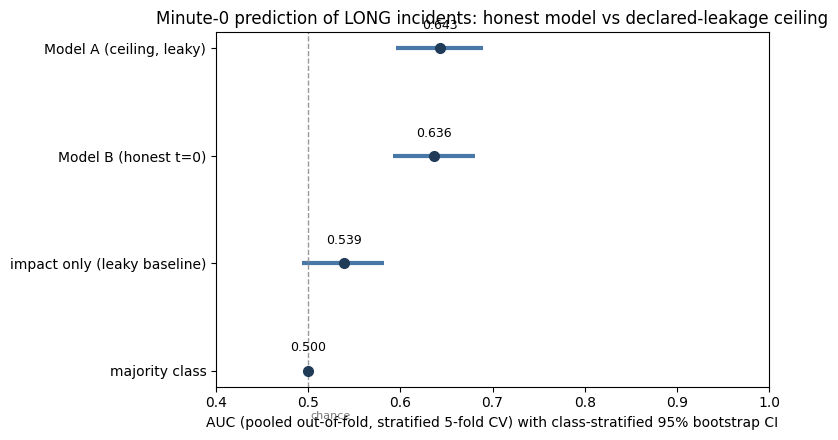

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
names = ["majority class", "impact only (leaky baseline)", "Model B (honest t=0)", "Model A (ceiling, leaky)"]
points = [0.5, auc["impact_only"], auc["B"], auc["A"]]
cis = [None, ci["impact_only"], ci["B"], ci["A"]]
ypos = np.arange(len(names))
for i, (pt, c) in enumerate(zip(points, cis)):
    if c is not None:
        ax.plot(c, [i, i], color="#4878a8", linewidth=3, solid_capstyle="butt")
    ax.plot(pt, i, "o", color="#1f3b57", markersize=7, zorder=3)
    ax.text(pt, i + 0.18, f"{pt:.3f}", ha="center", fontsize=9)
ax.axvline(0.5, color="#999999", linestyle="--", linewidth=1)
ax.text(0.502, -0.45, "chance", fontsize=8, color="#777777")
ax.set_yticks(ypos, names)
ax.set_xlim(0.4, 1.0)
ax.set_xlabel("AUC (pooled out-of-fold, stratified 5-fold CV) with class-stratified 95% bootstrap CI")
ax.set_title("Minute-0 prediction of LONG incidents: honest model vs declared-leakage ceiling")
plt.tight_layout()
plt.show()

### Sensitivity: without Twilio

Twilio's 45 incidents sit in an 8-day window with a 60% LONG rate, plausibly one platform crisis generating correlated incidents, i.e. these are not 45 independent observations. If the model's performance leans on that cluster, the honest AUC is even lower than the headline.

In [9]:
d_full = d
d = d[d["provider"] != "twilio"].copy()
y = d["long"].values
print(f"Without twilio: n={len(d)}, positives={y.sum()}")
auc_B_noTw = roc_auc_score(y, cv_oof_probs(["provider", "biz"]))
auc_A_noTw = roc_auc_score(y, cv_oof_probs(["provider", "impact", "biz"]))
print(f"AUC Model B without twilio: {auc_B_noTw:.3f}   (headline: {auc['B']:.3f})")
print(f"AUC Model A without twilio: {auc_A_noTw:.3f}   (headline: {auc['A']:.3f})")
d = d_full
y = d["long"].values

Without twilio: n=729, positives=167
AUC Model B without twilio: 0.610   (headline: 0.636)
AUC Model A without twilio: 0.615   (headline: 0.643)


## 5. Result: with uncertainty

| Model | AUC | 95% CI (class-stratified bootstrap) |
|---|---|---|
| Majority class | 0.500 | — (by construction) |
| Impact only (settled label alone, leaky baseline) | 0.539 | [0.493, 0.583] |
| Model B — honest t=0 (provider + business hours) | 0.636 | [0.592, 0.681] |
| Model A — ceiling with declared leak (+ settled impact) | 0.643 | [0.595, 0.689] |
| Leakage gap (A − B) | 0.006 | [−0.008, 0.020] |

Three readings, roughly in order of importance.

The honest minute-0 model lands at AUC 0.636, squarely inside the 0.5–0.7 range I declared upfront as the expected honest outcome. It is real but weak signal, and it is almost entirely provider identity: knowing "this is a Twilio or Figma incident, not an Anthropic one" is most of what minute 0 tells you. Drop Twilio, the correlated-crisis cluster, and Model B falls to 0.610. Had it come out near 0.9 instead, the right conclusion would not have been success; it would have been a leak somewhere in the pipeline.

The leakage gap is essentially zero — adding the settled impact label moves AUC by 0.006, with a confidence interval of [−0.008, 0.020] that straddles zero comfortably. I built this notebook expecting the settled impact to smuggle in outcome information, and conditional on provider, it turns out to carry almost none. The impact-only baseline explains why: pooled across 17 providers with incompatible labeling conventions, the settled label alone is nearly chance, at 0.539. Figma's "none" and Discord's "major" are drowning whatever within-provider severity signal might exist underneath. So the feared leak is real in principle (a settled label genuinely does encode more than a minute-0 label could) but small in this pooled, convention-confounded form in practice, and that gap between principle and practice is itself the finding: even the leaked, end-of-incident severity label would not have rescued minute-0 prediction here.

What the CV number means, and does not mean, matters as much as the number itself. AUC 0.636 measures discrimination across a random split of this observation period. It is not an estimate of performance on future incidents, which is what an escalation policy actually needs — provider LONG rates estimated on windows ranging from 8 days to roughly 6 years have no particular reason to stay put.

## 6. What I would do differently

The clearest implication is also the most useful: don't build a minute-0 escalation trigger from status-page metadata. Model B is near-null in the sense that matters operationally: at AUC ~0.64, driven almost entirely by provider identity, the "model" collapses into a lookup table of provider base rates, and those base rates are estimated from windows that differ by orders of magnitude, with the strongest one, Twilio, likely a single correlated crisis rather than 45 independent data points.

Since minute-0 information cannot separate long incidents from short ones, the defensible policy keys escalation on elapsed time instead: escalate any provider incident still open past a threshold, whether that's the combined P75 itself (~3.5 hours) or a per-provider median pulled from NB02. Elapsed time is the one predictor of remaining duration that a status page hands you for free, with no leakage attached.

The impact label fares no better as triage input across providers, and for a specific reason: the settled label (which knows strictly more than any minute-0 label could, since it is written after the incident resolves) only added ~0.006 AUC once provider was already in the model. If the more informed label can't help, the less informed one certainly can't. A provider's labeling conventions would need to be learned and calibrated per provider before an impact field is worth anything operationally.

If minute-0 prediction is still worth pursuing, the missing ingredient is data, not modeling. A status-page history capture (recording the initial impact declaration and every upgrade, with timestamps) would remove the leak and create the real t=0 feature in one move. That's a data-engineering decision I'd make before touching a model again.

## 7. Where I would not follow this data

- Whether minute-0 prediction is impossible, full stop — only that it is impossible with these features. A provider's internal telemetry at declaration time (error rates, blast radius, on-call load) might predict duration well; I observe none of it.
- The true value of the initial impact declaration. My snapshot captured the settled label, and the leak turned out small conditional on provider, but that doesn't tell me what the genuine minute-0 label would have contributed. It could be more informative, being a fresher assessment, or less, if it defaults to a cautious "investigating" severity.
- Generalization to future incidents. Stratified CV validates within this period; the 194 positives arrive from 17 providers observed over windows spanning 8 days to roughly 6 years, and the Twilio cluster alone shows how non-stationary and correlated the underlying process is.
- Anything about incident rates. Per-provider observation windows differ by orders of magnitude, and this notebook deliberately makes no frequency claims.
- Anything about undeclared failures. Status pages are self-reported; the LONG/short distinction applies only to incidents a provider chose to publish, with whatever duration that provider chose to record.